### load Dataset

In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)

df = pd.read_csv("C:/Users/Saran/OneDrive/Documents/Project/Dataset/startup.csv")

In [2]:
df.head()

,Startup_Name,state_code,zip_code,city,name,founded_at,closed_at,first_funding_at,last_funding_at,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,category_code,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,Startup_1,CA,92101,San Diego,Bandsintown,01-01-2007,NaN,04-01-2009,01-01-2010,2.2493,3.0027,4.6685,6.7041,3,3,,3,music,0,1,0,0,0,0,1.0000,0,acquired
1,Startup_2,CA,95032,Los Gatos,TriCipher,01-01-2000,NaN,2/14/2005,12/28/2009,5.1260,9.9973,7.0055,7.0055,9,4,40100000,1,enterprise,1,0,0,1,1,1,4.7500,1,acquired
2,Startup_3,CA,92121,San Diego,Plixi,3/18/2009,NaN,3/30/2010,3/30/2010,1.0329,1.0329,1.4575,2.2055,5,1,2600000,2,web,0,0,1,0,0,0,4.0000,1,acquired
3,Startup_4,CA,95014,Cupertino,Solidcore Systems,01-01-2002,NaN,2/17/2005,4/25/2007,3.1315,5.3151,6.0027,6.0027,5,3,40000000,1,software,0,0,0,1,1,1,3.3333,1,acquired
4,Startup_5,CA,94105,San Francisco,Inhale Digital,08-01-2010,10-01-2012,08-01-2010,04-01-2012,0.0000,1.6685,0.0384,0.0384,2,2,1300000,1,games_video,1,1,0,0,0,0,1.0000,1,closed


In [3]:
df.isnull().sum()

Startup_Name                  0
state_code                    0
zip_code                      0
city                          0
name                          0
founded_at                    0
closed_at                   588
first_funding_at              0
last_funding_at               0
age_first_funding_year        0
age_last_funding_year         0
age_first_milestone_year    152
age_last_milestone_year     152
relationships                 0
funding_rounds                0
funding_total_usd             0
milestones                    0
category_code                 0
has_VC                        0
has_angel                     0
has_roundA                    0
has_roundB                    0
has_roundC                    0
has_roundD                    0
avg_participants              0
is_top500                     0
status                        0
dtype: int64

In [5]:
# Fill null values with median
df["age_first_milestone_year"].fillna(df["age_first_milestone_year"].median(), inplace=True)
df["age_last_milestone_year"].fillna(df["age_last_milestone_year"].median(), inplace=True)
# Check remaining nulls
print(df[["age_first_milestone_year", "age_last_milestone_year"]].isna().sum())

df.to_csv("C:/Users/Saran/OneDrive/Documents/Project/Dataset/startup_data_no_null.csv")

age_first_milestone_year    0
age_last_milestone_year     0
dtype: int64


In [57]:
df.to_csv("C:/Users/Saran/OneDrive/Documents/Project/Dataset/startup_data_no_null.csv")

#### Analysis for NUMERICAL VARIABLES

In [9]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

numerical_vars = [
    "age_first_funding_year",
    "age_last_funding_year",
    "age_first_milestone_year",
    "age_last_milestone_year",
    "relationships",
    "funding_rounds",
    "funding_total_usd",
    "milestones",
    "avg_participants"
]
for col in numerical_vars:
    df[col] = pd.to_numeric(df[col], errors="coerce")
# Dataset subset
num_df = df[numerical_vars]

# Function for Standard Error
def standard_error(x):
    return x.std(ddof=1) / np.sqrt(x.count())

# Create summary statistics table
summary = pd.DataFrame({
    "Min": num_df.min(),
    "Max": num_df.max(),
    "Mean": num_df.mean(),
    "Median": num_df.median(),
    "Mode": num_df.mode().iloc[0],
    "Std_Dev": num_df.std(),
    "Std_Error": num_df.apply(standard_error),
    "Skewness": num_df.apply(lambda x: skew(x.dropna())),
    "Kurtosis": num_df.apply(lambda x: kurtosis(x.dropna()))
})
pd.set_option("display.max_columns", None)
print(summary)


                                 Min           Max          Mean  \
age_first_funding_year       -9.0466  2.189590e+01  2.235630e+00   
age_last_funding_year        -9.0466  2.189590e+01  3.931456e+00   
age_first_milestone_year    -14.1699  2.468490e+01  2.967273e+00   
age_last_milestone_year      -7.0055  2.468490e+01  4.708687e+00   
relationships                 0.0000  6.300000e+01  7.710726e+00   
funding_rounds                1.0000  1.000000e+01  2.310943e+00   
funding_total_usd         11000.0000  5.700000e+09  2.544691e+07   
milestones                    0.0000  8.000000e+00  1.841820e+00   
avg_participants              1.0000  1.600000e+01  2.838586e+00   

                                Median          Mode       Std_Dev  \
age_first_funding_year    1.446600e+00  0.000000e+00  2.510449e+00   
age_last_funding_year     3.528800e+00  0.000000e+00  2.967910e+00   
age_first_milestone_year  2.520500e+00  2.520500e+00  2.727845e+00   
age_last_milestone_year   4.476700e+00 

#### Analysis for CATEGORICAL VARIABLES


In [8]:
cat_vars = [
    "status",
   "has_VC",
"has_angel",
"has_roundA",
"has_roundB",
"has_roundC",
"has_roundD",
"is_top500",
"category_code",
"city",
"name"
]

# Function to compute summary for categorical variables
summary_list = []

for col in cat_vars:
    freq = df[col].value_counts(dropna=False)
    perc = df[col].value_counts(normalize=True, dropna=False) * 100
    mode_val = freq.idxmax() if not freq.empty else None
    
    # Median only makes sense for ordinal/binary encoded values
    # If values are Yes/No, convert to 1/0 for median calculation
    if set(df[col].dropna().unique()).issubset({"Yes", "No"}):
        median_val = df[col].map({"Yes": 1, "No": 0}).median()
    else:
        median_val = None
    
    summary_list.append({
        "Variable": col,
        "Mode": mode_val,
        "Median (if binary)": median_val,
        "Count": freq.to_dict(),
        "Percentage": perc.round(2).to_dict()
    })

summary_df = pd.DataFrame(summary_list)
pd.set_option("display.max_columns", None)
print(summary_df)

         Variable             Mode Median (if binary)  \
0          status         acquired               None   
1          has_VC                0               None   
2       has_angel                0               None   
3      has_roundA                1               None   
4      has_roundB                0               None   
5      has_roundC                0               None   
6      has_roundD                0               None   
7       is_top500                1               None   
8   category_code         software               None   
9            city    San Francisco               None   
10           name  Redwood Systems               None   

                                                Count  \
0                    {'acquired': 597, 'closed': 326}   
1                                    {0: 622, 1: 301}   
2                                    {0: 688, 1: 235}   
3                                    {1: 469, 0: 454}   
4                             

In [9]:
# Numerical columns
num_cols = [
    "age_first_funding_year",
    "age_last_funding_year",
    "age_first_milestone_year",
    "age_last_milestone_year",
    "relationships",
    "funding_rounds",
    "funding_total_usd",
    "milestones",
    "avg_participants"
]

# Outlier detection using IQR
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_summary.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count
    })

# Convert to DataFrame
outlier_df = pd.DataFrame(outlier_summary)

print(outlier_df)


                   Variable            Q1            Q3           IQR  \
0    age_first_funding_year  5.767000e-01  3.575350e+00  2.998650e+00   
1     age_last_funding_year  1.669850e+00  5.560250e+00  3.890400e+00   
2  age_first_milestone_year  1.252100e+00  4.002700e+00  2.750600e+00   
3   age_last_milestone_year  2.930150e+00  6.039750e+00  3.109600e+00   
4             relationships  3.000000e+00  1.000000e+01  7.000000e+00   
5            funding_rounds  1.000000e+00  3.000000e+00  2.000000e+00   
6         funding_total_usd  2.812500e+06  2.473750e+07  2.192500e+07   
7                milestones  1.000000e+00  3.000000e+00  2.000000e+00   
8          avg_participants  1.500000e+00  3.800000e+00  2.300000e+00   

    Lower_Bound   Upper_Bound  Outlier_Count  
0 -3.921275e+00  8.073325e+00             21  
1 -4.165750e+00  1.139585e+01             12  
2 -2.873800e+00  8.128600e+00             46  
3 -1.734250e+00  1.070415e+01             41  
4 -7.500000e+00  2.050000e+01     

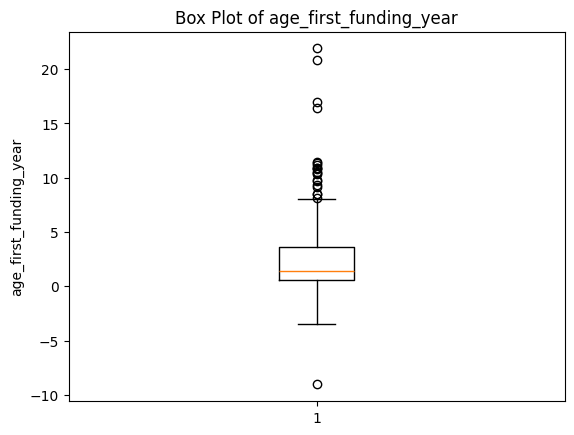

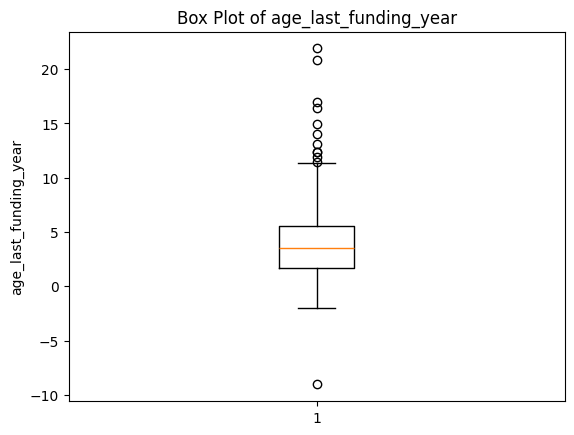

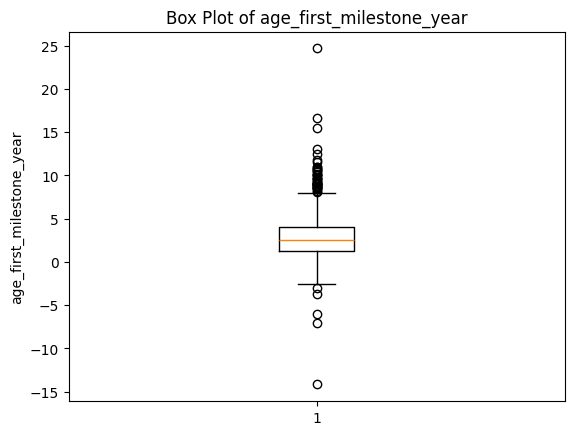

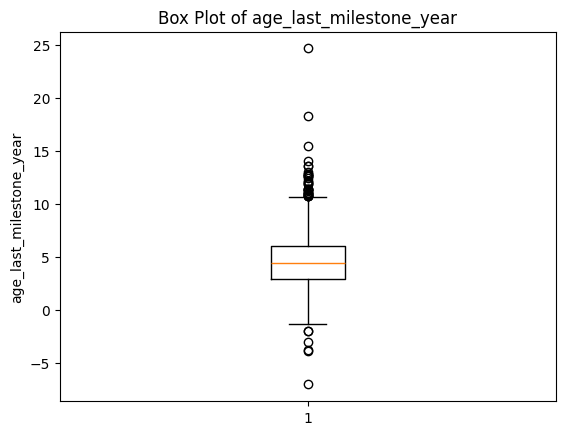

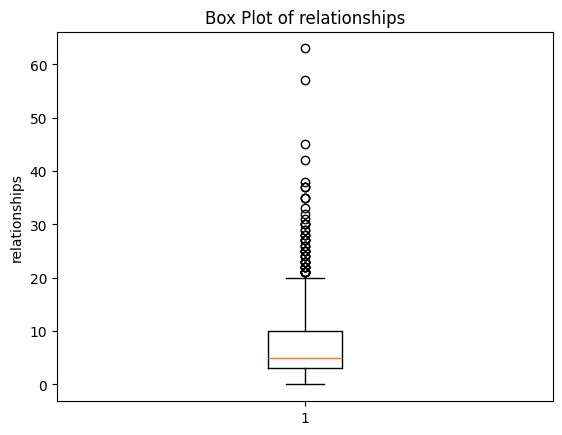

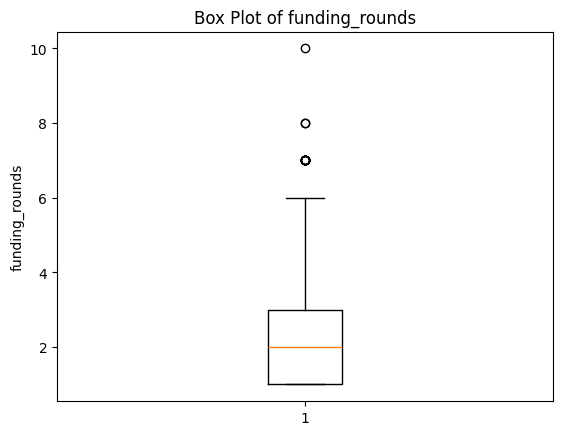

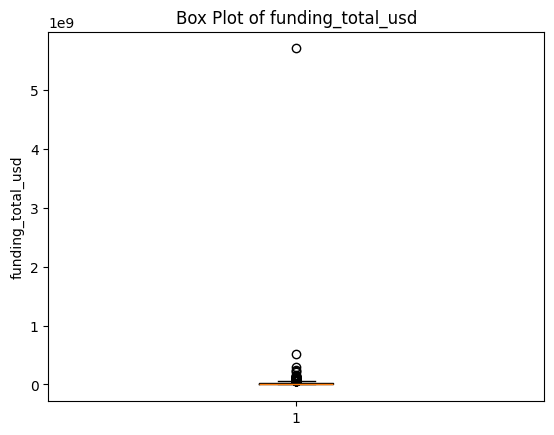

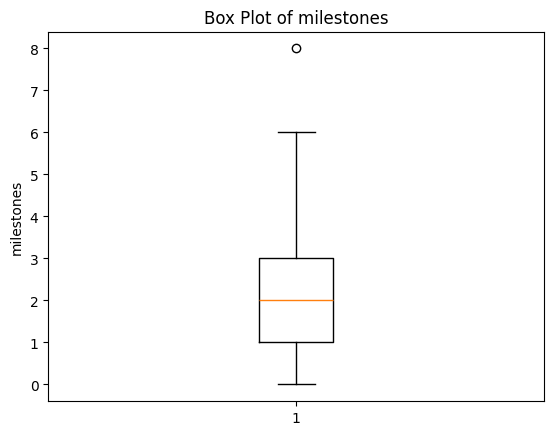

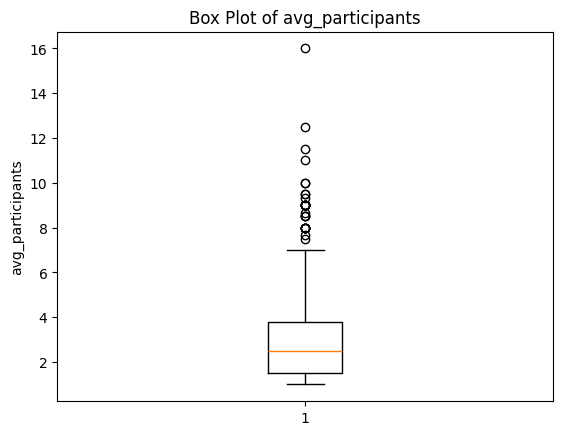

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Numerical columns
num_cols = [
    "age_first_funding_year",
    "age_last_funding_year",
    "age_first_milestone_year",
    "age_last_milestone_year",
    "relationships",
    "funding_rounds",
    "funding_total_usd",
    "milestones",
    "avg_participants"
]

# Box plots (one by one for clarity)
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)
    plt.show()


In [7]:
# 1. Define variables
# -----------------------------
numerical_vars = [
    'age_first_funding_year',
    'age_last_funding_year',
    'age_first_milestone_year',
    'age_last_milestone_year',
    'relationships',
    'funding_rounds',
    'funding_total_usd', 
    'milestones',
    'avg_participants'
]

cat_vars = [
    'state_code',
    'has_VC', 
    'has_angel',
    'has_roundA',
    'has_roundB',
    'has_roundC', 
    'has_roundD', 
    'is_top500'
]

### CHI-SQUARE Test for Categorical Variables


In [9]:
import pandas as pd
import itertools
from scipy.stats import chi2_contingency

# Select categorical variables
categorical_cols =  [ 
     "status",
   'has_VC',
    'has_angel',
    'has_roundA',
    'has_roundB',
    'has_roundC',
    'has_roundD',
    'is_top500'
]
print("Categorical Variables Found:", categorical_cols)

results = []

# Loop through each pair of categorical variables
for var1, var2 in itertools.combinations(categorical_cols, 2):
    
    # Create contingency table
    contingency = pd.crosstab(df[var1], df[var2])
    
    # Perform chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    # Store results
    results.append({
        "Variable 1": var1,
        "Variable 2": var2,
        "Chi-square": chi2,
        "p-value": p,
        "DF": dof,
        "Significance": "Significant" if p < 0.05 else "Not Significant"
    })

# Convert results to DataFrame
assoc_df = pd.DataFrame(results)
print(assoc_df)

Categorical Variables Found: ['status', 'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'has_roundD', 'is_top500']
    Variable 1  Variable 2  Chi-square       p-value  DF     Significance
0       status      has_VC    2.701215  1.002718e-01   1  Not Significant
1       status   has_angel    4.553598  3.284965e-02   1      Significant
2       status  has_roundA   30.586748  3.192670e-08   1      Significant
3       status  has_roundB   39.144057  3.936597e-10   1      Significant
4       status  has_roundC   24.589503  7.093710e-07   1      Significant
5       status  has_roundD   17.111250  3.525286e-05   1      Significant
6       status   is_top500   87.426883  8.745372e-21   1      Significant
7       has_VC   has_angel   37.779961  7.919106e-10   1      Significant
8       has_VC  has_roundA   35.537720  2.501591e-09   1      Significant
9       has_VC  has_roundB    0.006302  9.367275e-01   1  Not Significant
10      has_VC  has_roundC    2.976413  8.448630e-02  

# 1.Logistic Regression


===== TRAINING PERFORMANCE  =====
Confusion Matrix:
 [[150  78]
 [ 30 387]] 

Training Accuracy        : 0.8326
Training Sensitivity     : 0.9281
Training Specificity     : 0.6579
Training Precision       : 0.8323
Training NPV             : 0.8333
Training F1-Score        : 0.8776
Training ROC-AUC         : 0.8724

===== TESTING PERFORMANCE  =====
Confusion Matrix:
 [[ 56  42]
 [ 19 160]] 

Testing Accuracy         : 0.7798
Testing Sensitivity      : 0.8939
Testing Specificity      : 0.5714
Testing Precision        : 0.7921
Testing NPV              : 0.7467
Testing F1-Score         : 0.8399
Testing ROC-AUC          : 0.8353


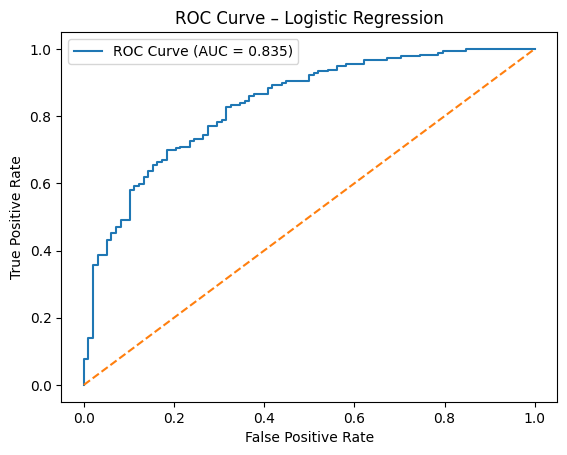

   has_VC  has_angel  has_roundA  has_roundB  has_roundC  has_roundD  \
1       1          0           0           1           1           1   
2       0          0           1           0           0           0   
3       0          0           0           1           1           1   
4       1          1           0           0           0           0   
5       0          0           0           1           0           0   

   is_top500  state_code_AZ  state_code_CA  state_code_CO  state_code_CT  \
1          1          False           True          False          False   
2          1          False           True          False          False   
3          1          False           True          False          False   
4          1          False           True          False          False   
5          1          False           True          False          False   

   state_code_DC  state_code_FL  state_code_GA  state_code_ID  state_code_IL  \
1          False          Fals

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_curve, auc, f1_score,roc_auc_score
)

# -----------------------------
# 1. Define variables
# -----------------------------
numerical_vars = [
    'age_first_funding_year',
    'age_last_funding_year',
    'age_first_milestone_year',
    'age_last_milestone_year',
    'relationships',
    'funding_rounds',
    'funding_total_usd', 
    'milestones',
    'avg_participants'
]

cat_vars = [
    'state_code',
    'has_VC', 
    'has_angel',
    'has_roundA',
    'has_roundB',
    'has_roundC', 
    'has_roundD', 
    'is_top500',
    'category_code', 
    'city'

]

TARGET = 'status'   # labels and status are same → use only one

# -----------------------------
# 2. Data preparation
# -----------------------------
df_model = df[numerical_vars + cat_vars + [TARGET]].copy()

# Convert numeric columns safely
for col in numerical_vars:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Drop missing values
df_model = df_model.dropna()

# Encode target (Binary)
y = df_model[TARGET].map({'acquired': 1, 'closed': 0})

# One-hot encode categorical predictors
X_cat = pd.get_dummies(df_model[cat_vars], drop_first=True)

# Scale numeric predictors
scaler = StandardScaler()
X_num = scaler.fit_transform(df_model[numerical_vars])

# Final feature matrix
X = np.hstack([X_num, X_cat.values])

# -----------------------------
# 3. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# 4. Logistic Regression Model
# -----------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# TRAINING PERFORMANCE
y_train_pred = model.predict(X_train)
y_train_prob = model.predict_proba(X_train)[:, 1]

cm_train = confusion_matrix(y_train, y_train_pred)
TN_tr, FP_tr, FN_tr, TP_tr = cm_train.ravel()

train_accuracy = accuracy_score(y_train, y_train_pred)
train_sensitivity = TP_tr / (TP_tr + FN_tr)        # Recall
train_specificity = TN_tr / (TN_tr + FP_tr)
train_precision = TP_tr / (TP_tr + FP_tr)
train_npv = TN_tr / (TN_tr + FN_tr)
train_f1 = (2 * train_precision * train_sensitivity) / \
           (train_precision + train_sensitivity)

train_auc = roc_auc_score(y_train, y_train_prob)

print("\n===== TRAINING PERFORMANCE  =====")
print("Confusion Matrix:\n", cm_train, "\n")
print(f"Training Accuracy        : {train_accuracy:.4f}")
print(f"Training Sensitivity     : {train_sensitivity:.4f}")
print(f"Training Specificity     : {train_specificity:.4f}")
print(f"Training Precision       : {train_precision:.4f}")
print(f"Training NPV             : {train_npv:.4f}")
print(f"Training F1-Score        : {train_f1:.4f}")
print(f"Training ROC-AUC         : {train_auc:.4f}")

# TESTING PERFORMANCE

cm_test = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm_test.ravel()

test_accuracy = accuracy_score(y_test, y_pred)
test_sensitivity = TP / (TP + FN)
test_specificity = TN / (TN + FP)
test_precision = TP / (TP + FP)
test_npv = TN / (TN + FN)
test_f1 = (2 * test_precision * test_sensitivity) / \
          (test_precision + test_sensitivity)

test_auc = roc_auc_score(y_test, y_prob)

print("\n===== TESTING PERFORMANCE  =====")
print("Confusion Matrix:\n", cm_test, "\n")
print(f"Testing Accuracy         : {test_accuracy:.4f}")
print(f"Testing Sensitivity      : {test_sensitivity:.4f}")
print(f"Testing Specificity      : {test_specificity:.4f}")
print(f"Testing Precision        : {test_precision:.4f}")
print(f"Testing NPV              : {test_npv:.4f}")
print(f"Testing F1-Score         : {test_f1:.4f}")
print(f"Testing ROC-AUC          : {test_auc:.4f}")

# -----------------------------
# 7. ROC Curve
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_lr = auc(fpr, tpr)


plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()


print(X_cat.head())

X_cat.to_csv("C:/Users/Saran/OneDrive/Documents/Project/Dataset/Dummy_CAT_Vars.csv", index=False)

# 2.Decision Tree


===== TRAINING PERFORMANCE =====
Confusion Matrix:
 [[146  82]
 [ 22 396]] 

Training Accuracy        : 0.8390
Training Sensitivity     : 0.9474
Training Specificity     : 0.6404
Training Precision       : 0.8285
Training NPV             : 0.8690
Training F1-Score        : 0.8839
Training ROC-AUC         : 0.8516

===== TESTING PERFORMANCE =====
Confusion Matrix:
 [[ 59  39]
 [ 20 159]] 

Testing Accuracy         : 0.7870
Testing Sensitivity      : 0.8883
Testing Specificity      : 0.6020
Testing Precision        : 0.8030
Testing NPV              : 0.7468
Testing F1-Score         : 0.8435
Testing ROC-AUC          : 0.7588


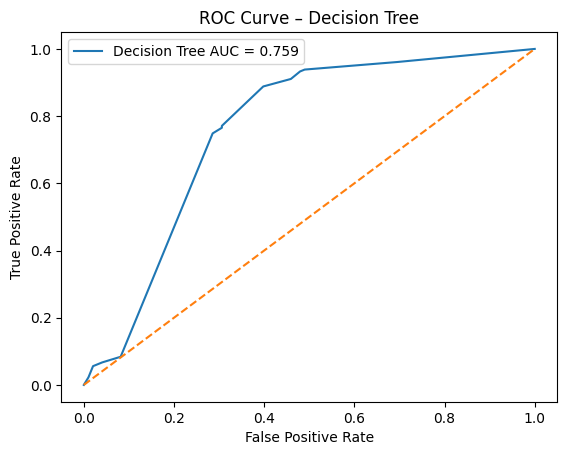

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_curve,
    roc_auc_score, auc
)

# -------------------------------
# 1. TARGET VARIABLE
# -------------------------------
TARGET = "status"

# -------------------------------
# 2. NUMERICAL VARIABLES
# -------------------------------
num_cols = [
    "age_first_funding_year",
    "age_last_funding_year",
    "age_first_milestone_year",
    "age_last_milestone_year",
    "relationships",
    "funding_rounds",
    "funding_total_usd",
    "milestones",
    "avg_participants"
]

# -------------------------------
# 3. CATEGORICAL VARIABLES
# -------------------------------
cat_cols = [
    "has_VC",
    "has_angel",
    "has_roundA",
    "has_roundB",
    "has_roundC",
    "has_roundD",
    "is_top500",
    "category_code",
    "state_code"
]

# -------------------------------
# 4. DATA PREPARATION
# -------------------------------

# Numeric handling
X_num = df[num_cols].apply(pd.to_numeric, errors="coerce")
X_num = X_num.fillna(X_num.median())

# Categorical handling
X_cat = df[cat_cols].fillna("Missing")
X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

# Combine
X = pd.concat([X_num, X_cat_encoded], axis=1)

# Encode Target
y = df[TARGET].map({"closed": 0, "acquired": 1})

# Remove missing target rows
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

# -------------------------------
# 5. TRAIN–TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# -------------------------------
# 6. DECISION TREE MODEL
# -------------------------------
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

# -------------------------------
# 7. TRAINING PERFORMANCE
# -------------------------------
y_train_pred = dt_model.predict(X_train)
y_train_prob = dt_model.predict_proba(X_train)[:, 1]

cm_train = confusion_matrix(y_train, y_train_pred)
TN_tr, FP_tr, FN_tr, TP_tr = cm_train.ravel()

train_accuracy = accuracy_score(y_train, y_train_pred)
train_sensitivity = TP_tr / (TP_tr + FN_tr)
train_specificity = TN_tr / (TN_tr + FP_tr)
train_precision = TP_tr / (TP_tr + FP_tr)
train_npv = TN_tr / (TN_tr + FN_tr)
train_f1 = (2 * train_precision * train_sensitivity) / \
           (train_precision + train_sensitivity)
train_auc = roc_auc_score(y_train, y_train_prob)

print("\n===== TRAINING PERFORMANCE =====")
print("Confusion Matrix:\n", cm_train, "\n")
print(f"Training Accuracy        : {train_accuracy:.4f}")
print(f"Training Sensitivity     : {train_sensitivity:.4f}")
print(f"Training Specificity     : {train_specificity:.4f}")
print(f"Training Precision       : {train_precision:.4f}")
print(f"Training NPV             : {train_npv:.4f}")
print(f"Training F1-Score        : {train_f1:.4f}")
print(f"Training ROC-AUC         : {train_auc:.4f}")

# -------------------------------
# 8. TESTING PERFORMANCE
# -------------------------------
y_test_pred = dt_model.predict(X_test)
y_test_prob = dt_model.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_test_pred)
TN, FP, FN, TP = cm_test.ravel()

test_accuracy = accuracy_score(y_test, y_test_pred)
test_sensitivity = TP / (TP + FN)
test_specificity = TN / (TN + FP)
test_precision = TP / (TP + FP)
test_npv = TN / (TN + FN)
test_f1 = (2 * test_precision * test_sensitivity) / \
          (test_precision + test_sensitivity)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\n===== TESTING PERFORMANCE =====")
print("Confusion Matrix:\n", cm_test, "\n")
print(f"Testing Accuracy         : {test_accuracy:.4f}")
print(f"Testing Sensitivity      : {test_sensitivity:.4f}")
print(f"Testing Specificity      : {test_specificity:.4f}")
print(f"Testing Precision        : {test_precision:.4f}")
print(f"Testing NPV              : {test_npv:.4f}")
print(f"Testing F1-Score         : {test_f1:.4f}")
print(f"Testing ROC-AUC          : {test_auc:.4f}")

# -------------------------------
# 9. ROC CURVE
# -------------------------------
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
auc_dt = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"Decision Tree AUC = {auc_dt:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Decision Tree")
plt.legend()
plt.show()


# Random Forest


===== TRAINING PERFORMANCE =====
Confusion Matrix:
 [[146  82]
 [ 22 396]] 

Training Accuracy        : 0.8390
Training Sensitivity     : 0.9474
Training Specificity     : 0.6404
Training Precision       : 0.8285
Training NPV             : 0.8690
Training F1-Score        : 0.8839
Training ROC-AUC         : 0.8516

===== TESTING PERFORMANCE =====
Confusion Matrix:
 [[ 59  39]
 [ 20 159]] 

Testing Accuracy         : 0.7870
Testing Sensitivity      : 0.8883
Testing Specificity      : 0.6020
Testing Precision        : 0.8030
Testing NPV              : 0.7468
Testing F1-Score         : 0.8435
Testing ROC-AUC          : 0.7588


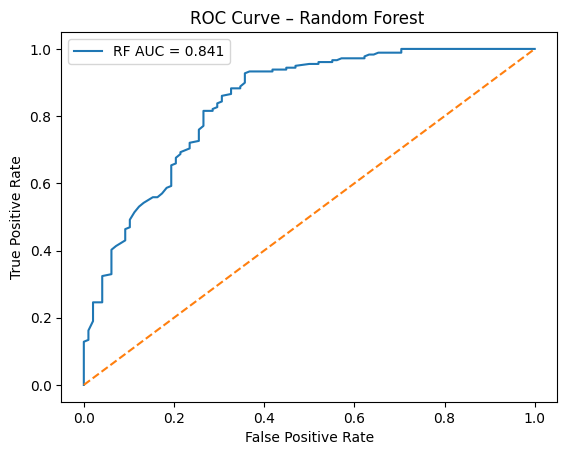

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_curve, auc, f1_score,roc_auc_score
)

# -------------------------------
# TARGET
# -------------------------------
TARGET = "status"

# -------------------------------
# NUMERICAL VARIABLES
# -------------------------------
num_cols = [
    "age_first_funding_year",
    "age_last_funding_year",
    "age_first_milestone_year",
    "age_last_milestone_year",
    "relationships",
    "funding_rounds",
    "funding_total_usd",
    "milestones",
    "avg_participants"
    
]

# -------------------------------
# CATEGORICAL VARIABLES
# -------------------------------
cat_cols = [
    "category_code",
    "state_code",
    "has_VC",
    "has_angel",
    "has_roundA",
    "has_roundB",
    "has_roundC",
    "has_roundD",
    "is_top500"
]

# -------------------------------
# DATA PREPARATION
# -------------------------------
X_num = df[num_cols].apply(pd.to_numeric, errors="coerce")
X_num = X_num.fillna(X_num.median())

X_cat = df[cat_cols].fillna("Missing")
X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

# Combine all features
X = pd.concat([X_num, X_cat_encoded], axis=1)

# -------------------------------
# TARGET ENCODING
# -------------------------------
y = df[TARGET].map({"closed": 0, "acquired": 1})

mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

# -------------------------------
# TRAIN–TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -------------------------------
# RANDOM FOREST MODEL
# -------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

# -------------------------------
# PREDICTION
# -------------------------------
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# -------------------------------
# 7. TRAINING PERFORMANCE
# -------------------------------
y_train_pred = dt_model.predict(X_train)
y_train_prob = dt_model.predict_proba(X_train)[:, 1]

cm_train = confusion_matrix(y_train, y_train_pred)
TN_tr, FP_tr, FN_tr, TP_tr = cm_train.ravel()

train_accuracy = accuracy_score(y_train, y_train_pred)
train_sensitivity = TP_tr / (TP_tr + FN_tr)
train_specificity = TN_tr / (TN_tr + FP_tr)
train_precision = TP_tr / (TP_tr + FP_tr)
train_npv = TN_tr / (TN_tr + FN_tr)
train_f1 = (2 * train_precision * train_sensitivity) / \
           (train_precision + train_sensitivity)
train_auc = roc_auc_score(y_train, y_train_prob)

print("\n===== TRAINING PERFORMANCE =====")
print("Confusion Matrix:\n", cm_train, "\n")
print(f"Training Accuracy        : {train_accuracy:.4f}")
print(f"Training Sensitivity     : {train_sensitivity:.4f}")
print(f"Training Specificity     : {train_specificity:.4f}")
print(f"Training Precision       : {train_precision:.4f}")
print(f"Training NPV             : {train_npv:.4f}")
print(f"Training F1-Score        : {train_f1:.4f}")
print(f"Training ROC-AUC         : {train_auc:.4f}")

# -------------------------------
# 8. TESTING PERFORMANCE
# -------------------------------
y_test_pred = dt_model.predict(X_test)
y_test_prob = dt_model.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_test_pred)
TN, FP, FN, TP = cm_test.ravel()

test_accuracy = accuracy_score(y_test, y_test_pred)
test_sensitivity = TP / (TP + FN)
test_specificity = TN / (TN + FP)
test_precision = TP / (TP + FP)
test_npv = TN / (TN + FN)
test_f1 = (2 * test_precision * test_sensitivity) / \
          (test_precision + test_sensitivity)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\n===== TESTING PERFORMANCE =====")
print("Confusion Matrix:\n", cm_test, "\n")
print(f"Testing Accuracy         : {test_accuracy:.4f}")
print(f"Testing Sensitivity      : {test_sensitivity:.4f}")
print(f"Testing Specificity      : {test_specificity:.4f}")
print(f"Testing Precision        : {test_precision:.4f}")
print(f"Testing NPV              : {test_npv:.4f}")
print(f"Testing F1-Score         : {test_f1:.4f}")
print(f"Testing ROC-AUC          : {test_auc:.4f}")

# -------------------------------
# ROC – AUC
# -------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr, tpr)
acc_rf = accuracy
f1_rf = f1

plt.plot(fpr, tpr, label=f"RF AUC = {auc_rf:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest ")
plt.legend()
plt.show()


# Support Vector Machine (SVM)


===== TRAINING PERFORMANCE =====
Confusion Matrix:
 [[194  34]
 [349  69]] 

Training Accuracy        : 0.4071
Training Sensitivity     : 0.1651
Training Specificity     : 0.8509
Training Precision       : 0.6699
Training NPV             : 0.3573
Training F1-Score        : 0.2649
Training ROC-AUC         : 0.5083

===== TESTING PERFORMANCE =====
Confusion Matrix:
 [[ 86  12]
 [145  34]] 

Testing Accuracy         : 0.4332
Testing Sensitivity      : 0.1899
Testing Specificity      : 0.8776
Testing Precision        : 0.7391
Testing NPV              : 0.3723
Testing F1-Score         : 0.3022
Testing ROC-AUC          : 0.5348


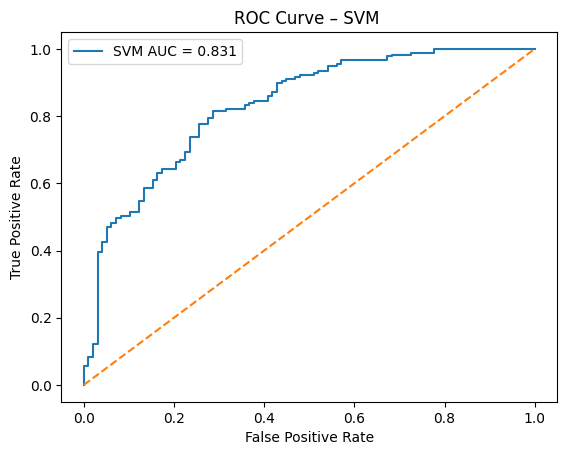

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_curve, auc, f1_score,roc_auc_score
)

# -------------------------------
# TARGET
# -------------------------------
TARGET = "status"

# -------------------------------
# NUMERICAL VARIABLES
# -------------------------------
num_cols = [
    "age_first_funding_year",
    "age_last_funding_year",
    "age_first_milestone_year",
    "age_last_milestone_year",
    "relationships",
    "funding_rounds",
    "funding_total_usd",
    "milestones",
    "avg_participants"
]

# -------------------------------
# CATEGORICAL VARIABLES
# -------------------------------
cat_cols = [
    "category_code",
    "state_code",
    "has_VC",
    "has_angel",
    "has_roundA",
    "has_roundB",
    "has_roundC",
    "has_roundD",
    "is_top500"
]

# -------------------------------
# DATA PREPARATION
# -------------------------------
X_num = df[num_cols].apply(pd.to_numeric, errors="coerce")
X_num = X_num.fillna(X_num.median())

# SCALE NUMERIC DATA (IMPORTANT FOR SVM)
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
X_num_scaled = pd.DataFrame(X_num_scaled, columns=num_cols, index=df.index)

X_cat = df[cat_cols].fillna("Missing")
X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

# Combine features
X = pd.concat([X_num_scaled, X_cat_encoded], axis=1)

# -------------------------------
# TARGET ENCODING
# -------------------------------
y = df[TARGET].map({"closed": 0, "acquired": 1})

mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

# -------------------------------
# TRAIN–TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -------------------------------
# SVM MODEL (RBF)
# -------------------------------
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

# -------------------------------
# PREDICTION
# -------------------------------
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# -------------------------------
# 7. TRAINING PERFORMANCE
# -------------------------------
y_train_pred = dt_model.predict(X_train)
y_train_prob = dt_model.predict_proba(X_train)[:, 1]

cm_train = confusion_matrix(y_train, y_train_pred)
TN_tr, FP_tr, FN_tr, TP_tr = cm_train.ravel()

train_accuracy = accuracy_score(y_train, y_train_pred)
train_sensitivity = TP_tr / (TP_tr + FN_tr)
train_specificity = TN_tr / (TN_tr + FP_tr)
train_precision = TP_tr / (TP_tr + FP_tr)
train_npv = TN_tr / (TN_tr + FN_tr)
train_f1 = (2 * train_precision * train_sensitivity) / \
           (train_precision + train_sensitivity)
train_auc = roc_auc_score(y_train, y_train_prob)

print("\n===== TRAINING PERFORMANCE =====")
print("Confusion Matrix:\n", cm_train, "\n")
print(f"Training Accuracy        : {train_accuracy:.4f}")
print(f"Training Sensitivity     : {train_sensitivity:.4f}")
print(f"Training Specificity     : {train_specificity:.4f}")
print(f"Training Precision       : {train_precision:.4f}")
print(f"Training NPV             : {train_npv:.4f}")
print(f"Training F1-Score        : {train_f1:.4f}")
print(f"Training ROC-AUC         : {train_auc:.4f}")

# -------------------------------
# 8. TESTING PERFORMANCE
# -------------------------------
y_test_pred = dt_model.predict(X_test)
y_test_prob = dt_model.predict_proba(X_test)[:, 1]

cm_test = confusion_matrix(y_test, y_test_pred)
TN, FP, FN, TP = cm_test.ravel()

test_accuracy = accuracy_score(y_test, y_test_pred)
test_sensitivity = TP / (TP + FN)
test_specificity = TN / (TN + FP)
test_precision = TP / (TP + FP)
test_npv = TN / (TN + FN)
test_f1 = (2 * test_precision * test_sensitivity) / \
          (test_precision + test_sensitivity)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\n===== TESTING PERFORMANCE =====")
print("Confusion Matrix:\n", cm_test, "\n")
print(f"Testing Accuracy         : {test_accuracy:.4f}")
print(f"Testing Sensitivity      : {test_sensitivity:.4f}")
print(f"Testing Specificity      : {test_specificity:.4f}")
print(f"Testing Precision        : {test_precision:.4f}")
print(f"Testing NPV              : {test_npv:.4f}")
print(f"Testing F1-Score         : {test_f1:.4f}")
print(f"Testing ROC-AUC          : {test_auc:.4f}")


acc_svm = accuracy
f1_svm = f1

# -------------------------------
# ROC – AUC
# -------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"SVM AUC = {auc_svm:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – SVM ")
plt.legend()
plt.show()


### comparison

In [17]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ==============================
# Logistic Regression
# ==============================
acc_lr = accuracy_score(y_test, y_pred)
f1_lr = f1_score(y_test, y_pred)
auc_lr = roc_auc_score(y_test, y_prob)

# ==============================
# Decision Tree
# ==============================
acc_dt = accuracy_score(y_test, y_test_pred)
f1_dt = f1_score(y_test, y_test_pred)
auc_dt = roc_auc_score(y_test, y_test_prob)

# ==============================
# Random Forest
# ==============================
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# ==============================
# SVM
# ==============================
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

# ==============================
# Create Comparison Table
# ==============================
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM (RBF)"
    ],
    "Accuracy": [
        acc_lr,
        acc_dt,
        acc_rf,
        acc_svm
    ],
    "F1-Score": [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_svm
    ],
    "ROC-AUC": [
        auc_lr,
        auc_dt,
        auc_rf,
        auc_svm
    ]
})

print("\n===== MODEL COMPARISON =====\n")
print(comparison_df.sort_values(by="ROC-AUC", ascending=False))


===== MODEL COMPARISON =====

                 Model  Accuracy  F1-Score   ROC-AUC
2        Random Forest  0.812274  0.861702  0.840725
3            SVM (RBF)  0.765343  0.827586  0.831034
1        Decision Tree  0.433213  0.302222  0.534774
0  Logistic Regression  0.548736  0.673629  0.525197
